In [8]:
# ── COMPLETE FIXED NOTEBOOK: REALISTIC DATA PREP WITH SLIDING WINDOWS ──────

# ============================================================================
# CELL 1: IMPORTS & CONFIGURATION
# ============================================================================
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Sliding window parameters
WINDOW_SIZE = 200      # Length of each window (timesteps)
STEP_SIZE = 50         # Overlap between windows

# Realistic split parameters
TEST_SIZE = 500
TEST_ANOMALY_RATIO = 0.01  # 1% anomalies in test
VAL_ANOMALY_RATIO = 0.5    # 50% anomalies in val

# Paths
RAW_PATH = Path("voraus-ad-dataset-100hz.parquet")
OUTPUT_DIR = Path("data/windowed_realistic")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Window size: {WINDOW_SIZE} timesteps")
print(f"  Step size: {STEP_SIZE} timesteps")

Configuration:
  Window size: 200 timesteps
  Step size: 50 timesteps


In [9]:
# ============================================================================
# CELL 2: LOAD AND PREPARE DATA
# ============================================================================
print("Loading raw data...")
df = pd.read_parquet(RAW_PATH)

# Remove metadata columns
METADATA_COLS = ['time', 'sample', 'anomaly', 'category', 'setting', 'action', 'active']
all_sensors = [c for c in df.columns if c not in METADATA_COLS]

# Remove constant sensors
constant_sensors = [col for col in all_sensors if df[col].nunique() <= 1]
sensors_to_keep = [col for col in all_sensors if col not in constant_sensors]

print(f"Keeping {len(sensors_to_keep)} sensors")

# Get sample-level metadata
sample_meta = df.groupby('sample').agg(
    anomaly=('anomaly', 'first'),
    n_timesteps=('time', 'count')
).reset_index()

# Filter to samples with enough timesteps
min_timesteps = WINDOW_SIZE
valid_samples = sample_meta[sample_meta['n_timesteps'] >= min_timesteps]
normal_samples = valid_samples[~valid_samples['anomaly']]
anomaly_samples = valid_samples[valid_samples['anomaly']]

print(f"\nValid samples (≥{min_timesteps} timesteps):")
print(f"  Normal: {len(normal_samples)}")
print(f"  Anomaly: {len(anomaly_samples)}")

Loading raw data...
Keeping 129 sensors

Valid samples (≥200 timesteps):
  Normal: 1367
  Anomaly: 755


In [10]:
# ============================================================================
# CELL 3: SLIDING WINDOW FUNCTION
# ============================================================================
def extract_windows(sample_ids, df, sensors, window_size, step_size, get_labels=True):
    """
    Extract sliding windows from sequences.
    
    Returns:
        X_windows: array of windows
        y_windows: labels (0=normal, 1=anomaly) if get_labels=True
        source_samples: list of source sample IDs
    """
    X_windows = []
    y_windows = []
    source_samples = []
    
    for sample_id in sample_ids:
        # Get sample data
        sample_data = df[df['sample'] == sample_id]
        sensor_data = sample_data[sensors].values
        anomaly_flags = sample_data['anomaly'].values if get_labels else None
        
        # Slide window across the sequence
        for start in range(0, len(sensor_data) - window_size + 1, step_size):
            window = sensor_data[start:start + window_size]
            X_windows.append(window)
            source_samples.append(sample_id)
            
            # Determine label for this window
            if get_labels and anomaly_flags is not None:
                window_anomalies = anomaly_flags[start:start + window_size]
                anomaly_ratio = window_anomalies.mean()
                # Label as anomaly if >50% of window is anomalous
                y_windows.append(1 if anomaly_ratio >= 0.5 else 0)
            elif get_labels:
                y_windows.append(0)  # Training windows are all normal
    
    X_windows = np.array(X_windows)
    y_windows = np.array(y_windows) if y_windows else None
    
    return X_windows, y_windows, source_samples

print("Sliding window function defined")

Sliding window function defined


In [11]:
# ============================================================================
# CELL 4: CREATE REALISTIC SPLITS WITH WINDOWS
# ============================================================================
print("Creating realistic splits with sliding windows...")

# Step 1: Create TEST set (sample-level)
n_test_normal = int(TEST_SIZE * (1 - TEST_ANOMALY_RATIO))
n_test_anomaly = TEST_SIZE - n_test_normal

test_normal_samples = normal_samples.sample(n=n_test_normal, random_state=RANDOM_STATE)
test_anomaly_samples = anomaly_samples.sample(n=n_test_anomaly, random_state=RANDOM_STATE)

print(f"\nTest set (sample-level):")
print(f"  Normal samples: {len(test_normal_samples)}")
print(f"  Anomaly samples: {len(test_anomaly_samples)}")

# Extract windows for test set
X_test_normal, _, _ = extract_windows(
    test_normal_samples['sample'], df, sensors_to_keep, 
    WINDOW_SIZE, STEP_SIZE, get_labels=True
)
X_test_anomaly, y_test_anomaly, _ = extract_windows(
    test_anomaly_samples['sample'], df, sensors_to_keep,
    WINDOW_SIZE, STEP_SIZE, get_labels=True
)

# Combine test windows
X_test = np.vstack([X_test_normal, X_test_anomaly])
y_test = np.hstack([np.zeros(len(X_test_normal)), y_test_anomaly])

print(f"\nTest set (window-level):")
print(f"  Total windows: {len(X_test)}")
print(f"  Normal windows: {(y_test==0).sum()}")
print(f"  Anomaly windows: {(y_test==1).sum()}")
print(f"  Anomaly rate: {y_test.mean():.2%}")

# Remove test samples from pool
remaining_normal = normal_samples.drop(test_normal_samples.index)
remaining_anomaly = anomaly_samples.drop(test_anomaly_samples.index)

# Step 2: Create VALIDATION set (balanced)
n_val_anomaly = min(250, len(remaining_anomaly))
n_val_normal = int(n_val_anomaly * (1 - VAL_ANOMALY_RATIO) / VAL_ANOMALY_RATIO)
n_val_normal = min(n_val_normal, len(remaining_normal))

val_normal_samples = remaining_normal.sample(n=n_val_normal, random_state=RANDOM_STATE)
val_anomaly_samples = remaining_anomaly.sample(n=n_val_anomaly, random_state=RANDOM_STATE)

# Extract windows for validation
X_val_normal, _, _ = extract_windows(
    val_normal_samples['sample'], df, sensors_to_keep,
    WINDOW_SIZE, STEP_SIZE, get_labels=True
)
X_val_anomaly, y_val_anomaly, _ = extract_windows(
    val_anomaly_samples['sample'], df, sensors_to_keep,
    WINDOW_SIZE, STEP_SIZE, get_labels=True
)

X_val = np.vstack([X_val_normal, X_val_anomaly])
y_val = np.hstack([np.zeros(len(X_val_normal)), y_val_anomaly])

print(f"\nValidation set (window-level):")
print(f"  Total windows: {len(X_val)}")
print(f"  Normal windows: {(y_val==0).sum()}")
print(f"  Anomaly windows: {(y_val==1).sum()}")
print(f"  Anomaly rate: {y_val.mean():.2%}")

# Step 3: Create TRAINING set (all remaining normal samples)
train_normal_samples = remaining_normal.drop(val_normal_samples.index)

# Extract ALL windows from training samples (augmentation!)
X_train, y_train, _ = extract_windows(
    train_normal_samples['sample'], df, sensors_to_keep,
    WINDOW_SIZE, STEP_SIZE, get_labels=True
)

print(f"\nTraining set (window-level with augmentation):")
print(f"  Original samples: {len(train_normal_samples)}")
print(f"  Generated windows: {len(X_train)}")
print(f"  Augmentation factor: {len(X_train)/len(train_normal_samples):.1f}x")

print(f"\n{'='*60}")
print("FINAL WINDOWED DATASET SUMMARY")
print('='*60)
print(f"Train: {X_train.shape} windows (all normal)")
print(f"Val:   {X_val.shape} windows ({y_val.sum()} anomalies)")
print(f"Test:  {X_test.shape} windows ({y_test.sum()} anomalies)")

Creating realistic splits with sliding windows...

Test set (sample-level):
  Normal samples: 495
  Anomaly samples: 5

Test set (window-level):
  Total windows: 9133
  Normal windows: 9040
  Anomaly windows: 93
  Anomaly rate: 1.02%

Validation set (window-level):
  Total windows: 9189
  Normal windows: 4555
  Anomaly windows: 4634
  Anomaly rate: 50.43%

Training set (window-level with augmentation):
  Original samples: 622
  Generated windows: 11330
  Augmentation factor: 18.2x

FINAL WINDOWED DATASET SUMMARY
Train: (11330, 200, 129) windows (all normal)
Val:   (9189, 200, 129) windows (4634.0 anomalies)
Test:  (9133, 200, 129) windows (93.0 anomalies)


In [12]:
# ============================================================================
# CELL 5: SCALE THE DATA
# ============================================================================
print("\nScaling data...")

# Reshape for scaling
n_train, T, F = X_train.shape
X_train_flat = X_train.reshape(-1, F)

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled_flat = scaler.fit_transform(X_train_flat)
X_train_scaled = X_train_scaled_flat.reshape(n_train, T, F).astype('float32')

# Scale validation
n_val, T, F = X_val.shape
X_val_scaled = scaler.transform(X_val.reshape(-1, F)).reshape(n_val, T, F).astype('float32')

# Scale test
n_test, T, F = X_test.shape
X_test_scaled = scaler.transform(X_test.reshape(-1, F)).reshape(n_test, T, F).astype('float32')

print(f"Data scaled to {X_train_scaled.dtype}")
print(f"Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"\nScaled shapes:")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Val:   {X_val_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}")


Scaling data...
Data scaled to float32
Mean: -0.0000, Std: 1.0000

Scaled shapes:
  Train: (11330, 200, 129)
  Val:   (9189, 200, 129)
  Test:  (9133, 200, 129)


In [13]:
# ============================================================================
# CELL 6: SAVE WINDOWED DATASET 
# ============================================================================
# Save arrays
np.savez_compressed(
    OUTPUT_DIR / "windowed_realistic_splits.npz",
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    X_test=X_test_scaled,
    y_val=y_val,
    y_test=y_test
)

# Save scaler
with open(OUTPUT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save configuration
config = {
    'window_size': WINDOW_SIZE,
    'step_size': STEP_SIZE,
    'n_features': F,
    'n_train_windows': len(X_train_scaled),
    'n_val_windows': len(X_val_scaled),
    'n_test_windows': len(X_test_scaled),
    'n_train_original_samples': len(train_normal_samples),
    'test_anomaly_rate': float(y_test.mean()),
    'val_anomaly_rate': float(y_val.mean()),
    'augmentation_factor': len(X_train_scaled) / len(train_normal_samples)
}

with open(OUTPUT_DIR / "config.pkl", "wb") as f:
    pickle.dump(config, f)

# Save sample IDs for reference
sample_ids = {
    'train_samples': train_normal_samples['sample'].tolist(),
    'val_normal_samples': val_normal_samples['sample'].tolist(),
    'val_anomaly_samples': val_anomaly_samples['sample'].tolist(),
    'test_normal_samples': test_normal_samples['sample'].tolist(),
    'test_anomaly_samples': test_anomaly_samples['sample'].tolist()
}

with open(OUTPUT_DIR / "sample_ids.pkl", "wb") as f:
    pickle.dump(sample_ids, f)

print("\n✓ Windowed dataset saved!")
print(f"  Location: {OUTPUT_DIR}")
print(f"  Training windows: {len(X_train_scaled)}")
print(f"  Augmentation factor: {config['augmentation_factor']:.1f}x")
print(f"  Test anomaly rate: {config['test_anomaly_rate']:.2%}")


✓ Windowed dataset saved!
  Location: data/windowed_realistic
  Training windows: 11330
  Augmentation factor: 18.2x
  Test anomaly rate: 1.02%


In [14]:
# ============================================================================
# CELL 7: VERIFICATION
# ============================================================================
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)

# Reload and verify
data = np.load(OUTPUT_DIR / "windowed_realistic_splits.npz")
X_train_loaded = data['X_train']
X_val_loaded = data['X_val']
X_test_loaded = data['X_test']
y_val_loaded = data['y_val']
y_test_loaded = data['y_test']

# Check shapes
assert X_train_loaded.shape == X_train_scaled.shape
assert X_val_loaded.shape == X_val_scaled.shape
assert X_test_loaded.shape == X_test_scaled.shape

# Check for NaNs
assert not np.isnan(X_train_loaded).any(), "NaNs found!"

print(f"✓ Train: {X_train_loaded.shape}")
print(f"✓ Val:   {X_val_loaded.shape} (anomalies: {y_val_loaded.sum()})")
print(f"✓ Test:  {X_test_loaded.shape} (anomalies: {y_test_loaded.sum()})")
print(f"✓ Test anomaly rate: {y_test_loaded.mean():.2%} (realistic!)")
print(f"✓ No NaN values found")

print("\nData preparation complete! Ready for model training.")


VERIFICATION
✓ Train: (11330, 200, 129)
✓ Val:   (9189, 200, 129) (anomalies: 4634.0)
✓ Test:  (9133, 200, 129) (anomalies: 93.0)
✓ Test anomaly rate: 1.02% (realistic!)
✓ No NaN values found

Data preparation complete! Ready for model training.


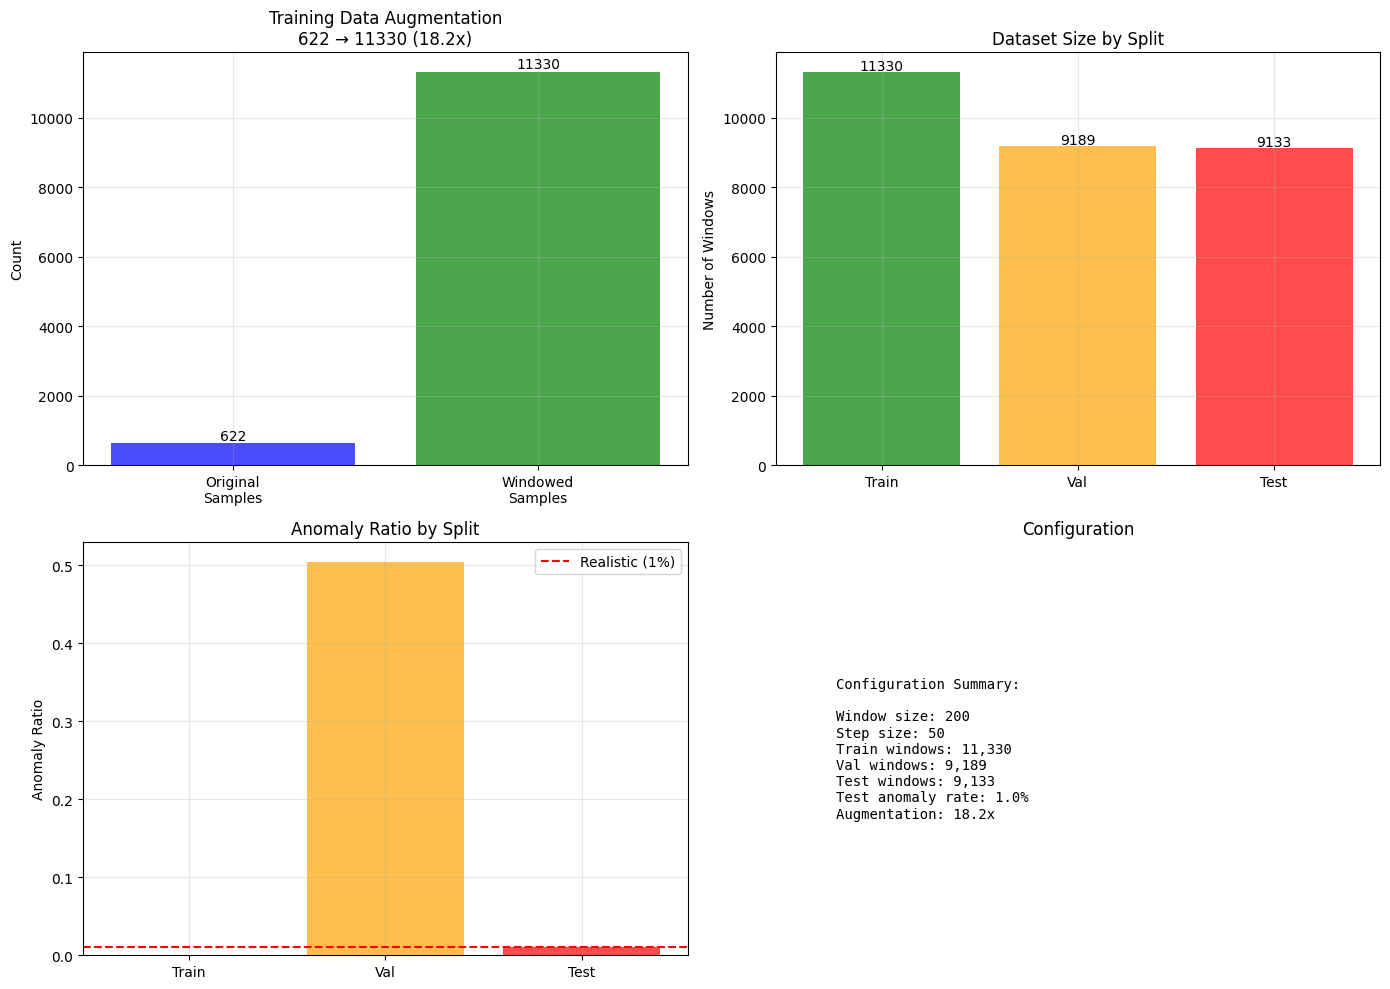


✓ Visualization saved to data/windowed_realistic/windowed_dataset_summary.png


In [15]:
# ============================================================================
# CELL 8: VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training data augmentation
axes[0,0].bar(['Original\nSamples', 'Windowed\nSamples'], 
              [len(train_normal_samples), len(X_train_scaled)], 
              color=['blue', 'green'], alpha=0.7)
axes[0,0].set_ylabel('Count')
axes[0,0].set_title(f'Training Data Augmentation\n{len(train_normal_samples)} → {len(X_train_scaled)} ({len(X_train_scaled)/len(train_normal_samples):.1f}x)')
axes[0,0].grid(True, alpha=0.3)
for i, v in enumerate([len(train_normal_samples), len(X_train_scaled)]):
    axes[0,0].text(i, v + 100, str(v), ha='center', fontsize=10)

# 2. Dataset size comparison
splits = ['Train', 'Val', 'Test']
window_counts = [len(X_train_scaled), len(X_val_scaled), len(X_test_scaled)]
axes[0,1].bar(splits, window_counts, color=['green', 'orange', 'red'], alpha=0.7)
axes[0,1].set_ylabel('Number of Windows')
axes[0,1].set_title('Dataset Size by Split')
axes[0,1].grid(True, alpha=0.3)
for i, v in enumerate(window_counts):
    axes[0,1].text(i, v + 50, str(v), ha='center', fontsize=10)

# 3. Anomaly ratio by split
anomaly_ratios = [0, y_val.mean(), y_test.mean()]
axes[1,0].bar(splits, anomaly_ratios, color=['green', 'orange', 'red'], alpha=0.7)
axes[1,0].set_ylabel('Anomaly Ratio')
axes[1,0].set_title('Anomaly Ratio by Split')
axes[1,0].axhline(y=0.01, color='red', linestyle='--', label='Realistic (1%)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Summary text
summary_text = f"Configuration Summary:\n\n"
summary_text += f"Window size: {WINDOW_SIZE}\n"
summary_text += f"Step size: {STEP_SIZE}\n"
summary_text += f"Train windows: {len(X_train_scaled):,}\n"
summary_text += f"Val windows: {len(X_val_scaled):,}\n"
summary_text += f"Test windows: {len(X_test_scaled):,}\n"
summary_text += f"Test anomaly rate: {y_test.mean():.1%}\n"
summary_text += f"Augmentation: {len(X_train_scaled)/len(train_normal_samples):.1f}x"

axes[1,1].text(0.1, 0.5, summary_text, transform=axes[1,1].transAxes, 
               fontsize=10, verticalalignment='center', fontfamily='monospace')
axes[1,1].axis('off')
axes[1,1].set_title('Configuration')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'windowed_dataset_summary.png', dpi=150)
plt.show()

print(f"\n✓ Visualization saved to {OUTPUT_DIR}/windowed_dataset_summary.png")

In [16]:
# ============================================================================
# CELL 9: FINAL SUMMARY
# ============================================================================
print("\n" + "="*60)
print("WINDOWED REALISTIC DATA PREPARATION - COMPLETE")
print("="*60)

print(f"\n Dataset Statistics:")
print(f"  Training windows: {len(X_train_scaled):,} (from {len(train_normal_samples)} original sequences)")
print(f"  Validation windows: {len(X_val_scaled):,} ({y_val.sum():,} anomalies)")
print(f"  Test windows: {len(X_test_scaled):,} ({y_test.sum():,} anomalies)")
print(f"  Test anomaly rate: {y_test.mean():.2%} (realistic deployment scenario)")

print(f"\n Configuration:")
print(f"  Window size: {WINDOW_SIZE} timesteps")
print(f"  Step size: {STEP_SIZE} timesteps")
print(f"  Features: {F} sensors")
print(f"  Augmentation factor: {len(X_train_scaled)/len(train_normal_samples):.1f}x")

print(f"\n Saved Files:")
print(f"  {OUTPUT_DIR}/windowed_realistic_splits.npz")
print(f"  {OUTPUT_DIR}/scaler.pkl")
print(f"  {OUTPUT_DIR}/config.pkl")
print(f"  {OUTPUT_DIR}/sample_ids.pkl")

print(f"\n Ready for LSTM training!")
print(f"   LSTM input shape will be: (batch_size, {WINDOW_SIZE}, {F})")


WINDOWED REALISTIC DATA PREPARATION - COMPLETE

 Dataset Statistics:
  Training windows: 11,330 (from 622 original sequences)
  Validation windows: 9,189 (4,634.0 anomalies)
  Test windows: 9,133 (93.0 anomalies)
  Test anomaly rate: 1.02% (realistic deployment scenario)

 Configuration:
  Window size: 200 timesteps
  Step size: 50 timesteps
  Features: 129 sensors
  Augmentation factor: 18.2x

 Saved Files:
  data/windowed_realistic/windowed_realistic_splits.npz
  data/windowed_realistic/scaler.pkl
  data/windowed_realistic/config.pkl
  data/windowed_realistic/sample_ids.pkl

 Ready for LSTM training!
   LSTM input shape will be: (batch_size, 200, 129)
